# Shortcut Learning Detection

This notebook demonstrates how to use `saliencytools` to identify when a model is relying on a 'shortcut' (like a watermark) rather than the actual object of interest.

In [1]:
import sys
import os
# Add the root directory to sys.path so we can import saliencytools
sys.path.append(os.path.abspath(os.path.join('..')))

%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np

100.0%
100.0%
100.0%
100.0%


Training model with shortcut...
Epoch 1 complete
Epoch 2 complete

Saliency Analysis Results:
Correlation with Shortcut Mask: 0.7907
AUC with Shortcut Mask: 0.9965
Correlation with Digit Mask: 0.0098
AUC with Digit Mask: 0.7618

Conclusion: The model is primarily looking at the shortcut!

Visualization saved to shortcut_analysis.png


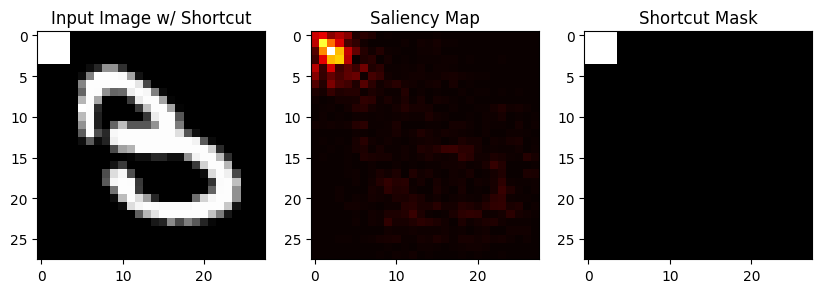

In [2]:
# Main Example Code
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from saliencytools.maskcompare import linear_correlation_coefficient, auc_judd, ssim, normalize_mask_0_1
import os

# 1. Simple CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def add_shortcut(images, labels, target_class=3):
    """Adds a 4x4 white square in the top-left corner for target_class."""
    modified_images = images.clone()
    mask = (labels == target_class)
    modified_images[mask, 0, 0:4, 0:4] = 1.0
    return modified_images

def get_saliency(model, image, target_class):
    """Computes a simple gradient-based saliency map."""
    image.requires_grad = True
    output = model(image)
    score = output[0, target_class]
    model.zero_grad()
    score.backward()
    saliency = image.grad.data.abs().squeeze().numpy()
    return normalize_mask_0_1(saliency)

def train_model(model, train_loader, epochs=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1} complete")

def main():
    # Load and preprocess data
    transform = transforms.Compose([transforms.ToTensor()])
    train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Simulate Shortcut Learning
    train_images = train_set.data.float().unsqueeze(1) / 255.0
    train_labels = train_set.targets
    shortcut_images = add_shortcut(train_images, train_labels)
    shortcut_dataset = torch.utils.data.TensorDataset(shortcut_images, train_labels)
    shortcut_loader = torch.utils.data.DataLoader(shortcut_dataset, batch_size=64, shuffle=True)

    print("Training model with shortcut...")
    model = SimpleCNN()
    train_model(model, shortcut_loader)

    # Test on a digit '3' with the shortcut
    test_images = test_set.data.float().unsqueeze(1) / 255.0
    test_labels = test_set.targets
    three_idx = (test_labels == 3).nonzero()[0].item()
    test_img = test_images[three_idx].unsqueeze(0)
    test_img_with_shortcut = add_shortcut(test_img, torch.tensor([3]))

    # Generate Saliency Map
    model.eval()
    saliency = get_saliency(model, test_img_with_shortcut, 3)

    # Create Ground Truth Masks
    # 1. Mask for the shortcut (top-left 4x4)
    shortcut_mask = np.zeros((28, 28))
    shortcut_mask[0:4, 0:4] = 1.0
    
    # 2. Mask for the digit (approximation using original image)
    digit_mask = normalize_mask_0_1(test_img.squeeze().numpy())

    # Quantitative Comparison using saliencytools metrics
    cc_shortcut = linear_correlation_coefficient(saliency, shortcut_mask)
    auc_shortcut = auc_judd(saliency, shortcut_mask)
    
    cc_digit = linear_correlation_coefficient(saliency, digit_mask)
    auc_digit = auc_judd(saliency, digit_mask)

    print("\nSaliency Analysis Results:")
    print(f"Correlation with Shortcut Mask: {cc_shortcut:.4f}")
    print(f"AUC with Shortcut Mask: {auc_shortcut:.4f}")
    print(f"Correlation with Digit Mask: {cc_digit:.4f}")
    print(f"AUC with Digit Mask: {auc_digit:.4f}")

    if cc_shortcut > cc_digit:
        print("\nConclusion: The model is primarily looking at the shortcut!")
    else:
        print("\nConclusion: The model is primarily looking at the digit.")

    # Save visualization
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.title("Input Image w/ Shortcut")
    plt.imshow(test_img_with_shortcut.detach().squeeze().numpy(), cmap='gray')
    plt.subplot(1, 3, 2)
    plt.title("Saliency Map")
    plt.imshow(saliency, cmap='hot')
    plt.subplot(1, 3, 3)
    plt.title("Shortcut Mask")
    plt.imshow(shortcut_mask, cmap='gray')
    plt.savefig("shortcut_analysis.png")
    print("\nVisualization saved to shortcut_analysis.png")

if __name__ == "__main__":
    main()
